# GROUP THREE JUPYTER NOTEBOOK

**The project is involving data cleaning and preprocessing to ensure that the data is safe for running machine learning models.**

**The cleaned data will then be explored through visualisations and statistical analysis methods used to pick insights about the dataset for cardiovascular disease and then the feature egineering and selection will be used to ensure that the best variables correlated with cardiovascualar disease are picked on to be used in the machine learning models**

**Various machine learning models will be trained and tested and these include the decision tree classifier, naive bayes classifier, logisitc regression, XG Boost model, and random forest model. The models will be evaluated on various metrics like precision, accuracy, recall, F1 score, confusion matrix, Receiver operating characterisitc area under curve, learning curves and the best model will be deployed using flask**

In [1]:
###Loading libraries
import pandas as pd 
import numpy as np 
import matplotlib as mat 
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

All the necessary libraries have been loaded

In [2]:
###Loading the dataset
df = pd.read_csv("cardio_train.csv", delimiter=';')
df.head(3)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1


The dataset has been loaded into the pandas data frame and the first 3 observations have been seen

In [3]:
##Checking for missing values
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

The dataset doesnt have any missing values in it

In [4]:
###Checking for duplicates
df. duplicated().sum()

np.int64(0)

The dataset doesnt have any duplicates in it

In [5]:
##Checking for data types
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

The dataset has 12 integers and one float variable

In [6]:
###Outliers checking
###Checking if our total payment variable has outliers (Total payment)

Q1= np.percentile(df['cardio'], 25, interpolation='midpoint')
Q3= np.percentile(df['cardio'], 75, interpolation='midpoint')
IQR= Q3-Q1
upper= df['cardio']>= (Q3+1.5*IQR)
lower= df['cardio']<= (Q1-1.5*IQR)
print("Upper bound:", upper)
print(np.where(upper))

print("lower bound:", lower)
print(np.where(lower))

Upper bound: 0        False
1        False
2        False
3        False
4        False
         ...  
69995    False
69996    False
69997    False
69998    False
69999    False
Name: cardio, Length: 70000, dtype: bool
(array([], dtype=int64),)
lower bound: 0        False
1        False
2        False
3        False
4        False
         ...  
69995    False
69996    False
69997    False
69998    False
69999    False
Name: cardio, Length: 70000, dtype: bool
(array([], dtype=int64),)


The target variable cardio doesnt have any outliers in it

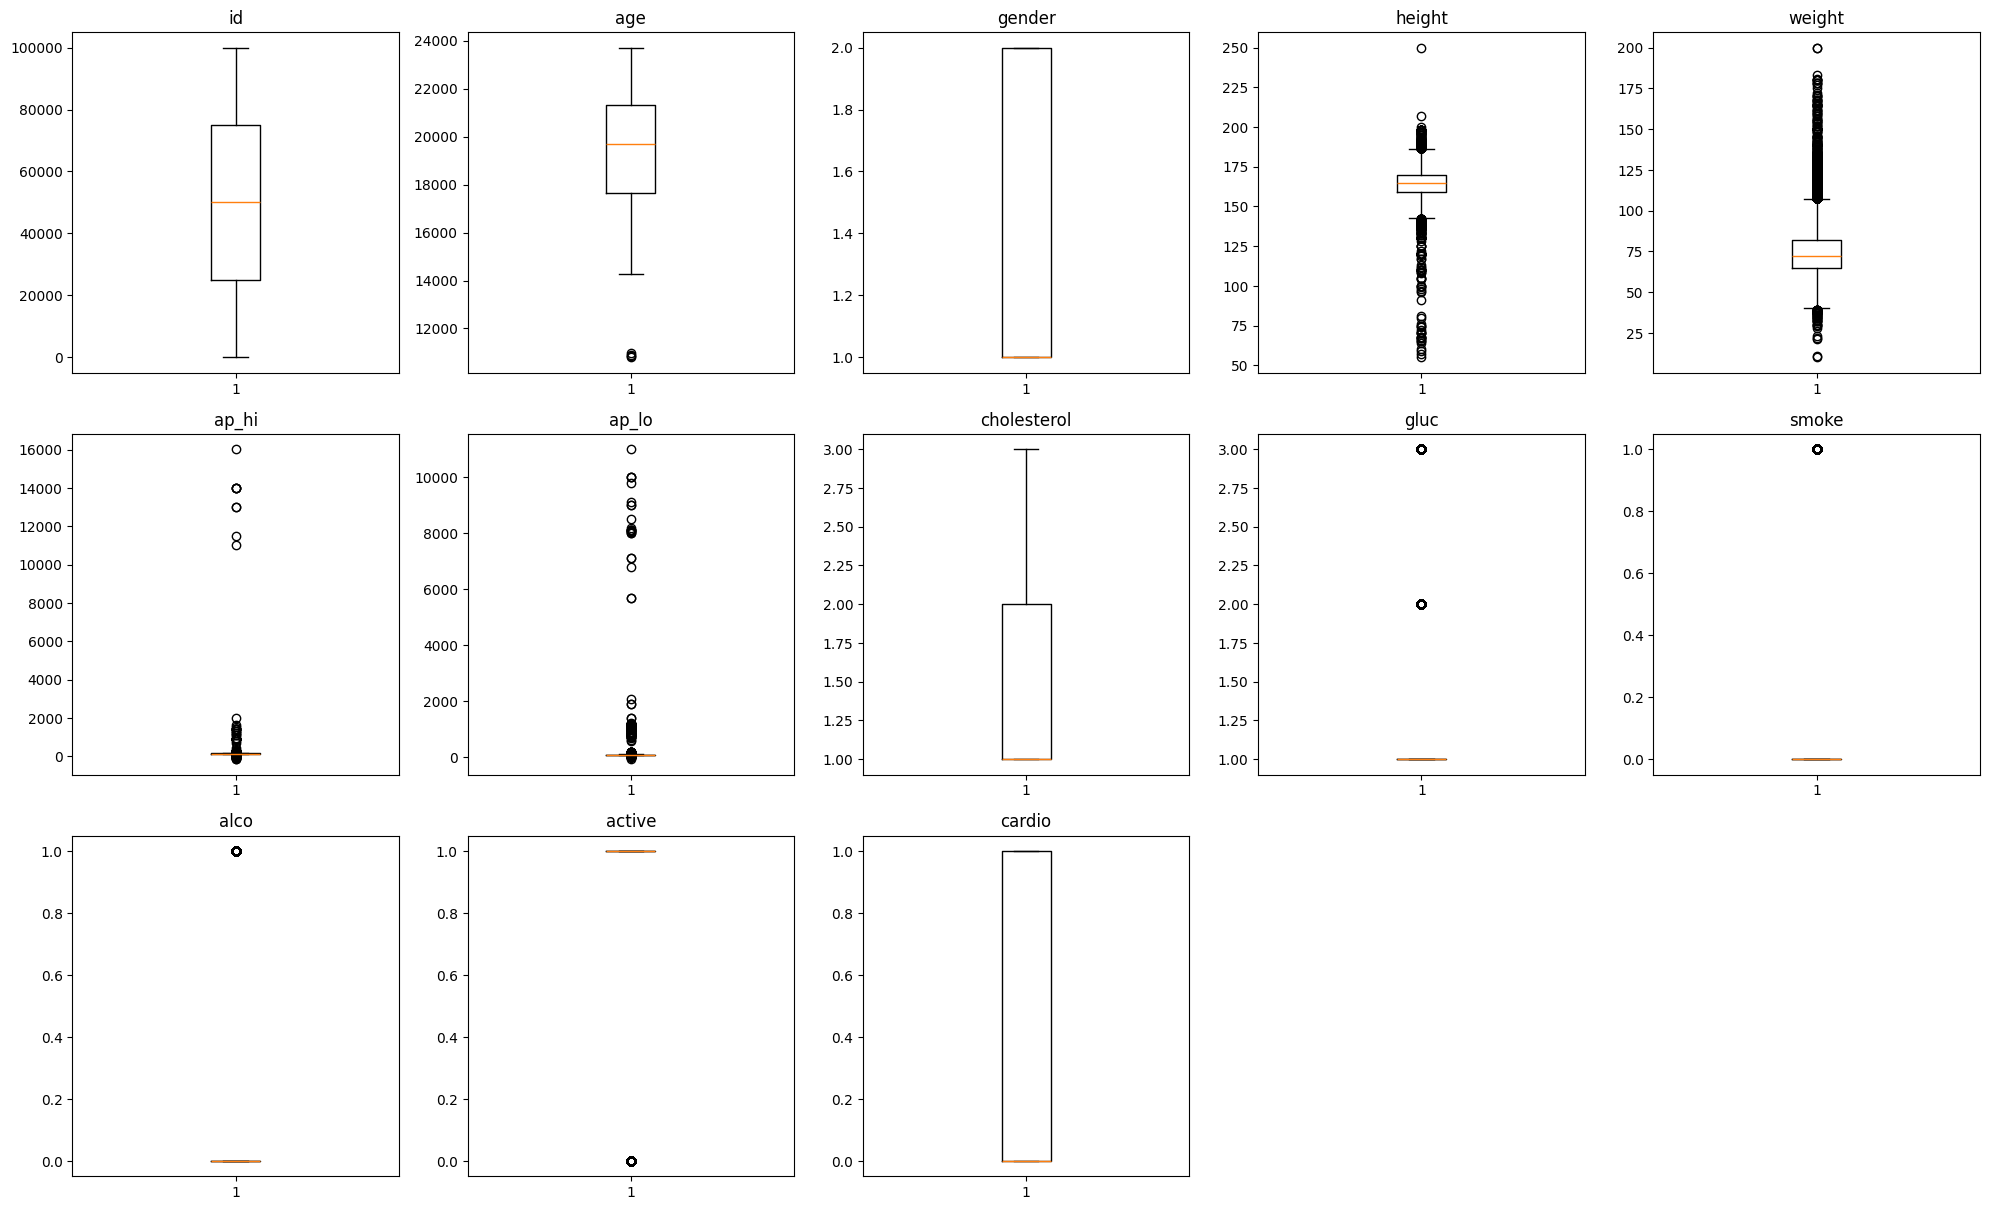

In [7]:
#### Boxplots visualisation of outliers in the dataset
def box_plotting(df, cont_cols):
    # Ensure cont_cols is a list of column names
    if not isinstance(cont_cols, list):
        raise TypeError("cont_cols should be a list of column names.")
    
    # Filter only numeric columns
    numeric_cols = [col for col in cont_cols if pd.api.types.is_numeric_dtype(df[col])]
    
    # Plot boxplots
    plt.figure(figsize=(20, 20))
    for i, col in enumerate(numeric_cols):
        plt.subplot(5, 5, i + 1)
        plt.boxplot(df[col].dropna())
        plt.title(col)
    
    plt.tight_layout()
    plt.show()

# Example usage
box_plotting(df, list(df.columns))  # Ensure you're passing a list of column names


Active has outliers in the lower bound

Alcohol has outliers in the upper bound

Smoke has outliers in the upper bound

Glucose has outliers in the upper bound

Blood pressure systolic has outliers in the upper bound

Blood pressure diastolic has outliers in the upper bound

Height and weight both have outliers in the lower and upper bound

Since this is clinical data where any outliers dropped can affect our models perfromance negatively, we decide not to drop them

In [8]:
# Basic info
print(df.describe())

                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814      1.349571    164.359229     74.205690   
std    28851.302323   2467.251667      0.476838      8.210126     14.395757   
min        0.000000  10798.000000      1.000000     55.000000     10.000000   
25%    25006.750000  17664.000000      1.000000    159.000000     65.000000   
50%    50001.500000  19703.000000      1.000000    165.000000     72.000000   
75%    74889.250000  21327.000000      2.000000    170.000000     82.000000   
max    99999.000000  23713.000000      2.000000    250.000000    200.000000   

              ap_hi         ap_lo   cholesterol          gluc         smoke  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean     128.817286     96.630414      1.366871      1.226457      0.088129   
std      154.011419    188.472530      0.680250    

The blood pressure systolic has an the hgihest value of 16020 which looks abnormal according to what the human scale can have and the maximum systolic value of 11000 which is also abnormal thus we create ranges according to the Intesnive care unit limitations to the ranges

In [9]:
# ICU-appropriate cleaning for systolic and diastolic blood pressure
df = df[(df['ap_hi'] >= 70) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 150)]


The blood pressure values ranges have been created

In [10]:
# Convert age from days to years
df['age'] = df['age'] / 365

Age has been converted from days to years

In [11]:
##Summary statistics
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,68754.000000,68754.000000,68754.000000,68754.000000,68754.000000,68754.000000,68754.000000,68754.000000,68754.000000,68754.000000,68754.000000,68754.000000,68754.000000
mean,49972.059997,53.327202,1.348765,164.361855,74.121367,126.614088,81.356692,1.364677,1.225834,0.088039,0.053568,0.803371,0.494808
std,28844.693766,6.761899,0.476583,8.185127,14.331902,16.744640,9.555033,0.678952,0.571791,0.283353,0.225164,0.397452,0.499977
min,0.000000,29.583562,1.000000,55.000000,11.000000,70.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,24998.500000,48.376027,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50009.500000,53.975342,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74860.750000,58.421918,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,64.967123,2.000000,250.000000,200.000000,240.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


The mean age of the patients is 53.339 years

The mean height of the patients is 164.359cm

The mean weight of the patients is 74.206kgs



In [12]:
###Saving the cleaned dataset for cardio vascular disease
data = df.to_csv("cardio_cleaned.csv")

In [13]:
####Loading the clean dataset
data = pd.read_csv("cardio_cleaned.csv")
print(data.describe())

         Unnamed: 0            id           age        gender        height  \
count  68754.000000  68754.000000  68754.000000  68754.000000  68754.000000   
mean   34999.244495  49972.059997     53.327202      1.348765    164.361855   
std    20202.789989  28844.693766      6.761899      0.476583      8.185127   
min        0.000000      0.000000     29.583562      1.000000     55.000000   
25%    17495.250000  24998.500000     48.376027      1.000000    159.000000   
50%    35006.500000  50009.500000     53.975342      1.000000    165.000000   
75%    52482.750000  74860.750000     58.421918      2.000000    170.000000   
max    69999.000000  99999.000000     64.967123      2.000000    250.000000   

             weight         ap_hi         ap_lo   cholesterol          gluc  \
count  68754.000000  68754.000000  68754.000000  68754.000000  68754.000000   
mean      74.121367    126.614088     81.356692      1.364677      1.225834   
std       14.331902     16.744640      9.555033    

The dataset descriptive statistics shows the mean age of 53.3 years

The maximum systolic value is 240 and the minimum is 70

The maximum diastolic value is 150 and the minimum is 40

The mean height is 164 cm

**Creating of bins for group age**

In [14]:
bins = np.linspace(min(data["age"]), max(data["age"]), 4)
bins

array([29.58356164, 41.37808219, 53.17260274, 64.96712329])

In [15]:
###Group names
group_names = ['<=40','41-69','>69']

In [16]:
data['age-binned'] = pd.cut(data['age'], bins, labels=group_names, include_lowest=True )
data[['age','age-binned']].head(7)

,age,age-binned
0,50.391781,41-69
1,55.419178,>69
2,51.663014,41-69
3,48.282192,41-69
4,47.873973,41-69
5,60.038356,>69
6,60.583562,>69


The age has been binned into various age groups where we have those people less than or equal to 40, 41 to 69, and greater than 69

In [17]:
###Checking for value counts in the ages of patients
data["age-binned"].value_counts()

age-binned
>69      37975
41-69    27193
<=40      3586
Name: count, dtype: int64

The number of people less than or equal to 40 years is 3586, those between 41 to 69 years are 27193, those greater than 69 years are 37975

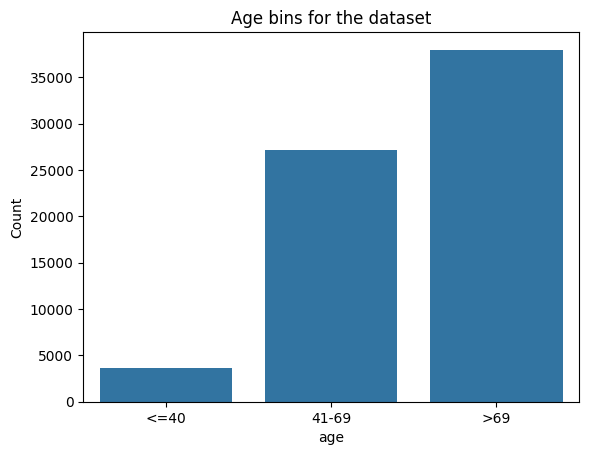

In [18]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

# Create a count plot using seaborn
sns.countplot(x='age-binned', data=data, order=group_names)

# Set labels and title
plt.xlabel("age")
plt.ylabel("Count")
plt.title("Age bins for the dataset")

# Show the plot
plt.show()


The visualisation shows that most of people in the dataset are greater than 69 years, followed by those between 41-69 and then those less than or equal to 40 were the least

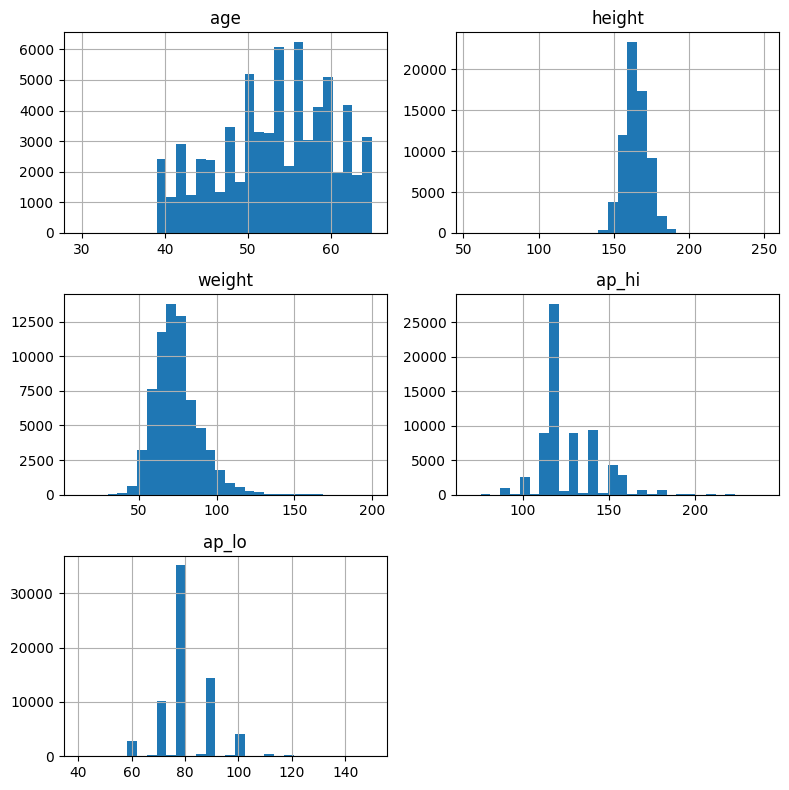

In [19]:
# Visualize numerical features
num_features = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
data[num_features].hist(bins=30, figsize=(8,8))
plt.tight_layout()
plt.show()

The age of patients is from 38 to 65 years and the distribution is skwed to the left meaning that majority of the patients are adults.

The height looks normally distributed

Weight looks skewed to the right

Blood pressure systolic is skewed to the right

Blood pressure diastolic is a bit normally distributed

In [20]:
###Correaltion analysis to confirm the relationship
from scipy.stats import pointbiserialr

for col in ['ap_hi']:
    corr, pval = pointbiserialr(data[col], data['cardio'])
    print(f'{col}: correlation = {corr:.3f}, p-value = {pval:.3f}')


ap_hi: correlation = 0.426, p-value = 0.000


The correlation analysis has a coeffecient of 0.426 shows a weak positive relationship between the 2 variables cardio and blood pressure systolic and this is significant since the p value is less than 0.05

In [21]:
###Correaltion analysis to confirm the relationship
from scipy.stats import pointbiserialr

for col in ['ap_lo']:
    corr, pval = pointbiserialr(data[col], data['cardio'])
    print(f'{col}: correlation = {corr:.3f}, p-value = {pval:.3f}')


ap_lo: correlation = 0.337, p-value = 0.000


The correlation coeffecient 0.337 shows a weak positive relationship between cardio and diastolic and this is significant since the p value 0.00 is less than 0.05

Text(0.5, 1.0, 'Box plot of weight for various gender')

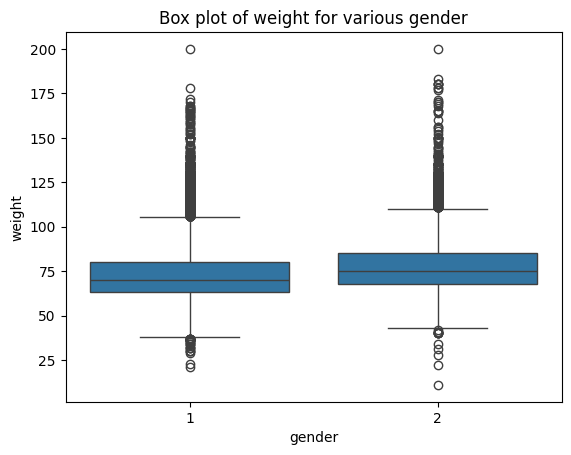

In [22]:

# Category Box plot
sns.boxplot(x="gender", y="weight", data=data)
plt.title("Box plot of weight for various gender")

The boxplot shows that the women (1) weight is skewed to the upper bound and they have outliers in both the upper and lower bound.

The boxplot shows that the men weight (2) is skewed to the upper bound and have outliers in both the upper and lower bound

The mean weight of the men is higher than that for the females

Text(0.5, 1.0, 'cholesterol versus alcohol')

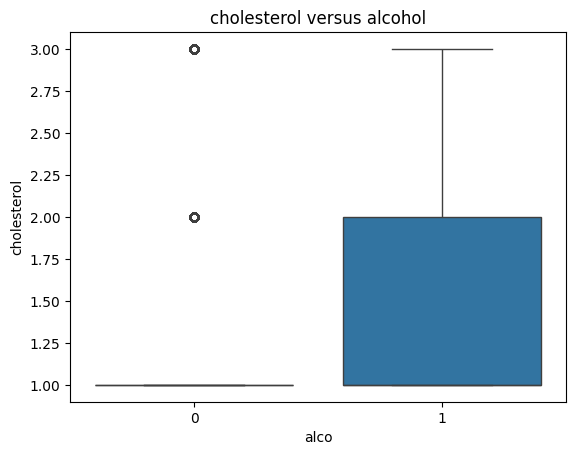

In [23]:

# Category Box plot
sns.boxplot(x="alco", y="cholesterol", data=data)
plt.title("cholesterol versus alcohol")

The alcoholics (1)  have high cholesterol levels as compared to the non alcoholics whose cholesterol levels are low but with some outliers in the upper bound

(0.0, 248.5)

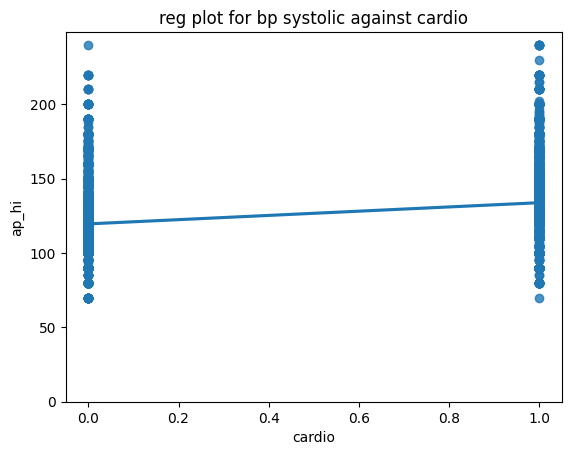

In [24]:
#Systolic as potential predictor variable of cardio
sns.regplot(x="cardio", y="ap_hi", data=data)
plt.title("reg plot for bp systolic against cardio")
plt.ylim(0,)

The regression plot doesnt shows a positive correlation between blood pressure diastolic and cardiovascular disease therefore we ran a correlation analysis between both variables

(0.0, 155.5)

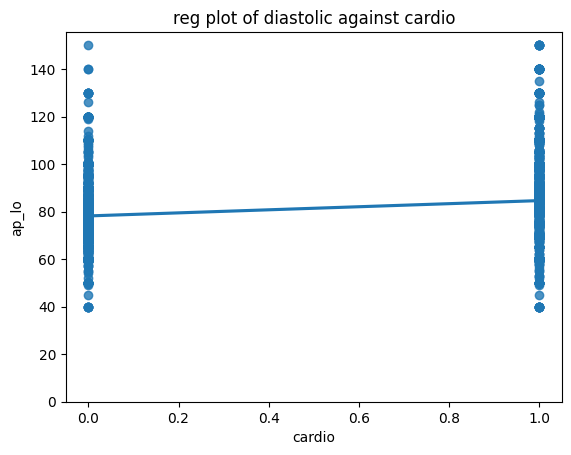

In [25]:
#Diastolic as potential predictor variable of cardio
sns.regplot(x="cardio", y="ap_lo", data=data)
plt.title("reg plot of diastolic against cardio")
plt.ylim(0,)

The regression plot shows a positive relationship between the variables for cardiovascular disease and blood pressure diastolic but we confirm this with statistics

In [26]:
# Convert height from cm to meters before calculating BMI
data['BMI'] = data['weight'] / ((data['height'] / 100) ** 2)

# Preview the updated DataFrame
print(data[['weight', 'height', 'BMI']].head(3))


   weight  height        BMI
0    62.0     168  21.967120
1    85.0     156  34.927679
2    64.0     165  23.507805


The variable body mass index has been created to make a unified relationship between weight and height

Ho: There is normal distribution

Ha: There is no normal distrbution

Text(0.5, 1.0, 'Distribution for weight')

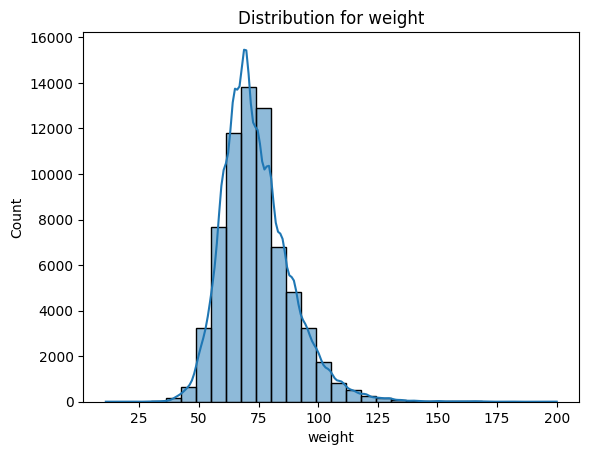

In [27]:
###Histogram for weight 
sns.histplot(data=data, x='weight', kde=True, bins=30)
plt.title("Distribution for weight")

The weight of the patients looks to be normally distributed therefore meaning that most of the data points lie around the mean

In [28]:
##We use the shapiro wil test to check for the normallity of the data
#Use of the shapiro wilks test to confirm
#Shapiro wilk test
from scipy.stats import shapiro
stat,p= shapiro(data['weight'])
print("Statistics:", stat)
print("p value:", p)

Statistics: 0.954079447996866
p value: 1.2242399480398595e-84


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68754.
  res = hypotest_fun_out(*samples, **kwds)


Since the p value is less than 0.05, we reject the null and conclude that there is no normal distribution and this is backed up by statistics at 95%

Text(0.5, 1.0, 'Height distribution')

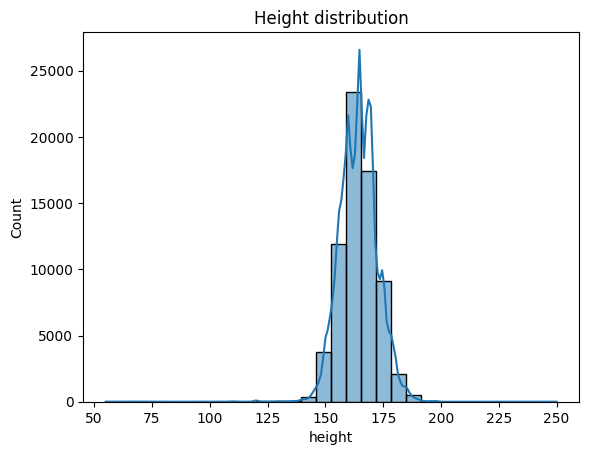

In [29]:
###Histogram for height
sns.histplot(data=data, x='height', kde=True, bins=30)
plt.title("Height distribution")

The distribution shows that its skewed to the left therefore meaning that most of the patients are heavy weighted

In [30]:
##We use the shapiro wil test to check for the normallity of the data
#Use of the shapiro wilks test to confirm
#Shapiro wilk test
from scipy.stats import shapiro
stat,p= shapiro(data['height'])
print("Statistics:", stat)
print("p value:", p)

Statistics: 0.9651198612964428
p value: 2.8592047082631323e-78


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68754.
  res = hypotest_fun_out(*samples, **kwds)


Since the p value is less than 0.05, we reject the null and conclude that the data is not normally distributed and this is significant at 96%

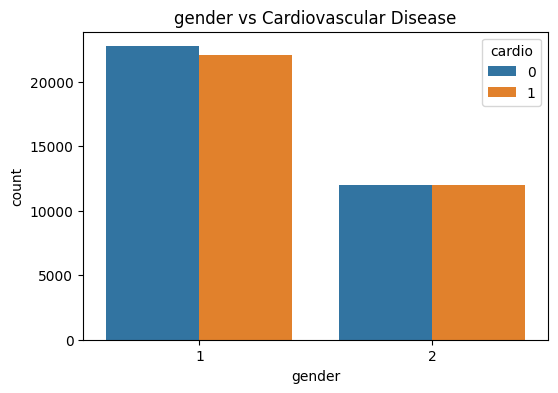

In [31]:
# Visualize categorical features
cat_features = ['gender']
for feature in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=feature, hue='cardio', data=data)
    plt.title(f'{feature} vs Cardiovascular Disease')
    plt.show()

The women having no cardiovascular disease are more than those with cardiovascualr disease by a small difference.

The men having cardiovascular disease and those with out have no significant  difference.

The women are more than the men in the dataset

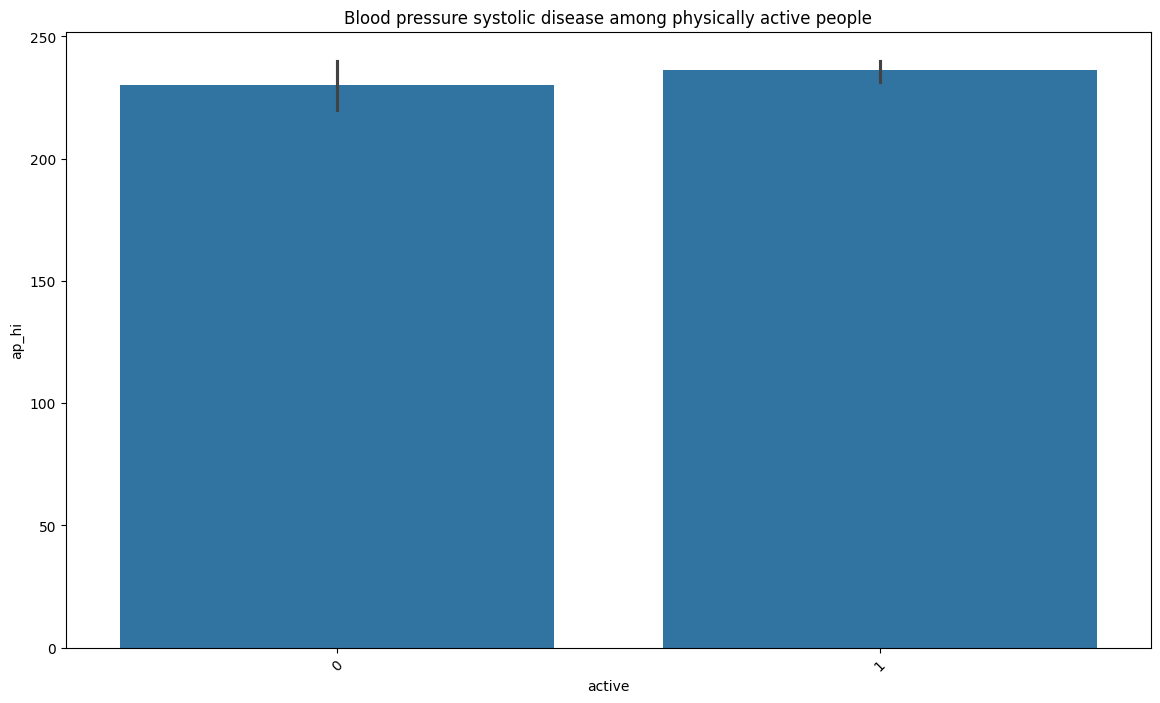

In [32]:
###blood pressure systolic vs physical activeness
plt.figure(figsize=(14, 8))
sns.barplot(x='active', y='ap_hi', data=data.nlargest(10, 'ap_hi'))
plt.title('Blood pressure systolic disease among physically active people')
plt.xticks(rotation=45)
plt.ylabel('ap_hi')
plt.show()

The barplots show that the physically inactive people are most likely to get the cardio vascular diseases than those that are active

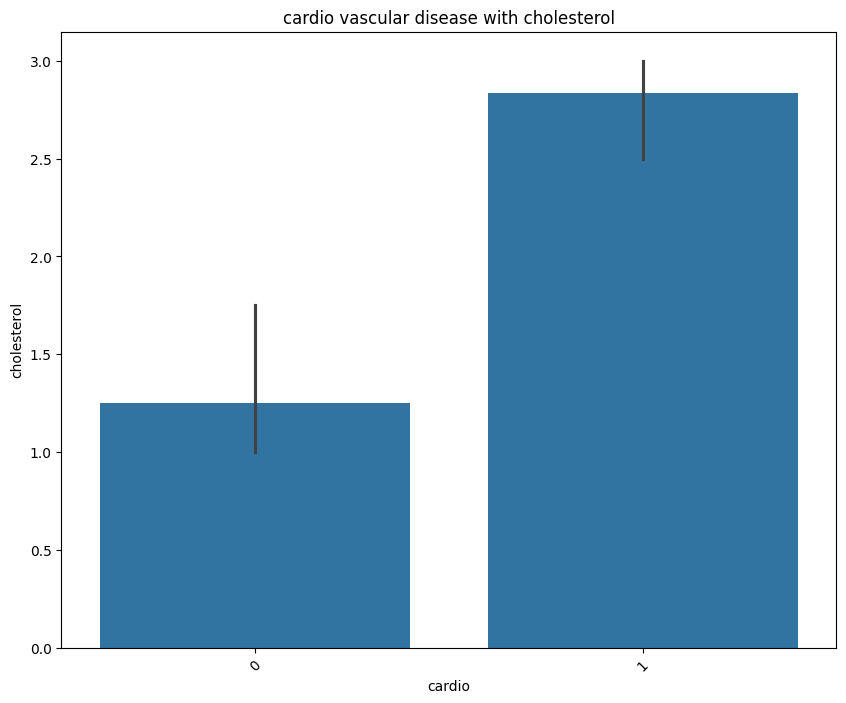

In [33]:
###cardio vs cholestorol
plt.figure(figsize=(10, 8))
sns.barplot(x='cardio', y='cholesterol', data=data.nlargest(10, 'gluc'))
plt.title('cardio vascular disease with cholesterol')
plt.xticks(rotation=45)
plt.ylabel('cholesterol')
plt.show()

The bar plot shows that people with cardio vascular diesease have high cholesterol levels as compared to those with low cholesterol levels

**Feature engineering**

Creating categories to see how the patient data looks regarding heart failure prediction

In [34]:
# Create blood pressure categories
data['bp_category'] = pd.cut(data['ap_hi'], 
                          bins=[0, 120, 140, 160, 180, 250],
                          labels=['Normal', 'Elevated', 'Hypertension Stage 1', 
                                  'Hypertension Stage 2', 'Hypertensive Crisis'])

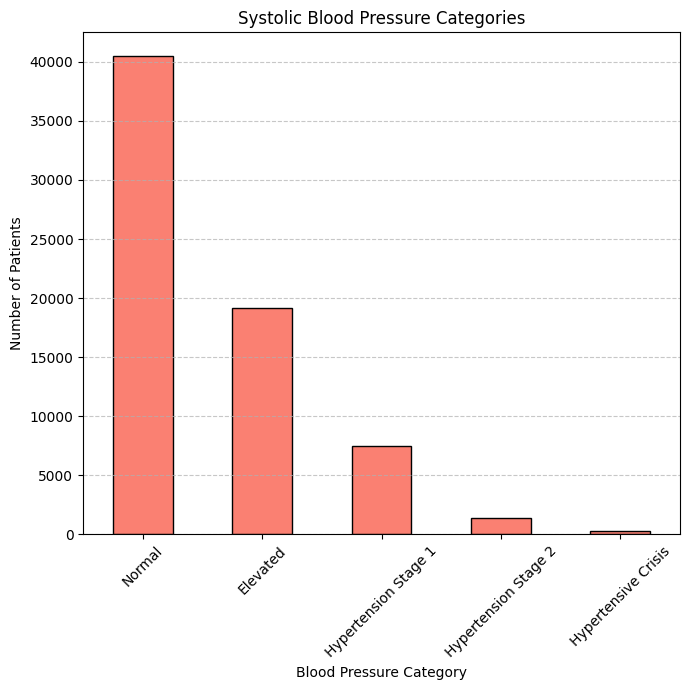

In [35]:
# Count each category
bp_counts = data['bp_category'].value_counts().sort_index()

# Plot the bar chart
plt.figure(figsize=(7, 7))
bp_counts.plot(
    kind='bar',
    color='salmon',
    edgecolor='black'
)
plt.title('Systolic Blood Pressure Categories')
plt.xlabel('Blood Pressure Category')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The baplot can show us that majority of our patients have normal heart rates, followed by those with elevated heart rates, then those with hypertensive stage 1, then those with hypertensive stage 2 and finally the least people are at hypertensive crisis stage

In [36]:
!pip install plotly

In [37]:
!pip install statsmodels

***Feature selection***

The features correlated with cardiovascular disease will be picked up for modell development

In [38]:
###Loading of the statsmodel libraries
import plotly.express as px
import missingno as msno
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings("ignore")

In [39]:
####Correaltion analysis using the ANOVA test since the target variable is continous
import statsmodels.api as sm
from statsmodels.formula.api import ols

# List of continuous variables to check
continuous_vars = ['age', 'height', 'weight', 'ap_hi', 'ap_lo','BMI','smoke','active','gluc','cholesterol','alco','gender']

# Significance level
alpha = 0.05

print("🔍 ANOVA Results: Checking which variables are significantly associated with 'cardio'\n")

for var in continuous_vars:
    model = ols(f'{var} ~ C(cardio)', data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_value = anova_table['PR(>F)'][0]

    if p_value < alpha:
        print(f"✅ 'cardio' is significantly correlated with '{var}' (p = {p_value:.4f})")
    else:
        print(f"❌ 'cardio' is NOT significantly correlated with '{var}' (p = {p_value:.4f})")


🔍 ANOVA Results: Checking which variables are significantly associated with 'cardio'

✅ 'cardio' is significantly correlated with 'age' (p = 0.0000)
✅ 'cardio' is significantly correlated with 'height' (p = 0.0050)
✅ 'cardio' is significantly correlated with 'weight' (p = 0.0000)
✅ 'cardio' is significantly correlated with 'ap_hi' (p = 0.0000)
✅ 'cardio' is significantly correlated with 'ap_lo' (p = 0.0000)
✅ 'cardio' is significantly correlated with 'BMI' (p = 0.0000)
✅ 'cardio' is significantly correlated with 'smoke' (p = 0.0000)
✅ 'cardio' is significantly correlated with 'active' (p = 0.0000)
✅ 'cardio' is significantly correlated with 'gluc' (p = 0.0000)
✅ 'cardio' is significantly correlated with 'cholesterol' (p = 0.0000)
✅ 'cardio' is significantly correlated with 'alco' (p = 0.0245)
❌ 'cardio' is NOT significantly correlated with 'gender' (p = 0.0589)


The correlation analysis shows that cardio vascular diease is correlated with age, body mass index, blood pressure sytolic, blood pressure diastolic, smoking, physical activity levels, glucose levels, cholesterol, alcohol.

Its not correlated with gender


 Overall Conclusion:

This exploratory analysis aimed to identify features associated with heart failure among patients using clinical data. The findings provide clear evidence that certain physiological and lifestyle factors are closely linked to the presence of cardiovascular disease.

The analysis revealed that:

Age, blood pressure (both systolic and diastolic), cholesterol levels, glucose levels, and body weight are significantly elevated in patients with cardiovascular disease.

These features show clear patterns and distributional differences when comparing patients with and without heart conditions, making them strong candidates for risk assessment and early detection.

Lifestyle-related variables such as physical activity, smoking, and alcohol intake showed weaker associations, though they may still play a role when combined with other risk factors.

Overall, the results align with established clinical understanding of cardiovascular risk and support the use of these features for developing early detection models and preventive strategies. These insights also lay a strong foundation for machine learning applications aimed at predicting heart failure risk based on routine health data.


# Modelling

# Decision tree classifier

A Decision Tree Classifier is a machine learning algorithm that uses a tree-like structure to make predictions by classifying data into different categories.

It operates through starting at the root node and branching out based on decision rules, ultimately reaching a leaf node that represents the final classification. 

In [40]:
###Loading the libraries for model selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

In [41]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define features and target
features = ['age', 'ap_hi', 'ap_lo', 'BMI', 'smoke', 'active', 'gluc', 'cholesterol', 'alco']
X = data[features]
y = data['cardio']

# Optional: split a test set for final evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the model
dt = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearch with K-Fold CV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

The model has been trained at 70% of the data and tested at 30% of the data 

The model is also hyperparamter tuned using grid search since its effective in model performance.

In [42]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

skf = StratifiedKFold(n_splits=5)
accuracies = []

for train_index, test_index in skf.split(X_train, y_train):
    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]
    
    grid_search.fit(X_train_fold, y_train_fold)
    dt_best = grid_search.best_estimator_
    
    y_pred_fold = dt_best.predict(X_test_fold)
    acc = accuracy_score(y_test_fold, y_pred_fold)
    accuracies.append(acc)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits


The model has been fitted on various k folds to ensure that we can check for the model consistency

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Estimator:
 DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.83      0.75     10380
           1       0.78      0.62      0.69     10247

    accuracy                           0.73     20627
   macro avg       0.73      0.72      0.72     20627
weighted avg       0.73      0.73      0.72     20627

Test Set Accuracy: 0.73


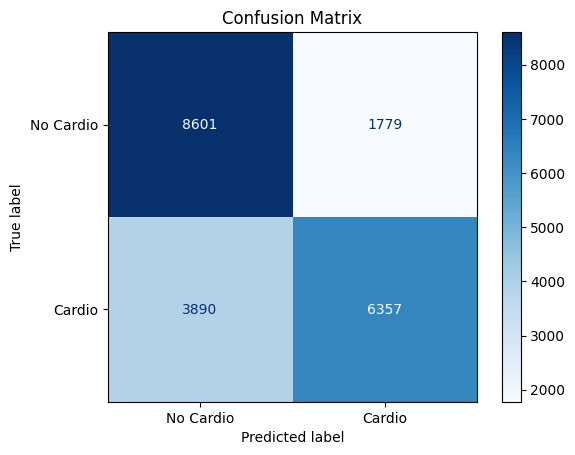

In [43]:

# Best model results
print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:\n", grid_search.best_estimator_)

# Evaluate on held-out test set
y_pred = grid_search.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.2f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Cardio', 'Cardio'], cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

The decision tree classifier has been fitted on 5 folds and the evaluation done for precision, recall, fi score and accuracy with an average accuracy of 73%

**Precision analysis**

Precision is high for class cardiovascular disease meaning that when it predicts heart failure its often correct

**Recall**

Recall is high for class no cardiovascular disease meaning that the model is better at identifying actual no cardiovascular disease.

**F1 score**

The F1 scores show a relative balance of trade offs between precision and recall

**Accuracy**

The accuracy level on the test set is at 73% which is a moderate performance

**Confusion matrix**

This means that out of the 20627 sample tests done the model correctly predicted 14958 tests which is 3 quarters of the testing data.



In [44]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, learning_curve
# Cross-validation
cv_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV ROC AUC: 0.637 ± 0.007


The model has the modest predictive ability for by the ROC AUC score of 0.637 therefore there is room for improvement

# RANDOM FOREST

A Random Forest is a machine learning algorithm that uses an ensemble of decision trees to make predictions. It works by creating multiple decision trees, each trained on a different random subset of the data and features, and then aggregating their predictions to produce a final result

In [45]:

# Select only the significant features (based on your ANOVA results)
features = [
    'age', 'ap_hi', 'ap_lo',
    'BMI', 'smoke', 'active', 'gluc', 'cholesterol', 'alco'
]
X = data[features]
y = data['cardio']

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the Random forest classifier
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# For tracking results
fold = 1
accuracies = []



The features that best bit the cardio vascualr disease are selected  and fitted in the random forest model with implementation of the k fold cross validation and the best paramters for the grid search are chosen out by the model


--- Fold 1 ---
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Fold Accuracy: 0.7270743945894844
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      6947
           1       0.75      0.67      0.71      6804

    accuracy                           0.73     13751
   macro avg       0.73      0.73      0.73     13751
weighted avg       0.73      0.73      0.73     13751



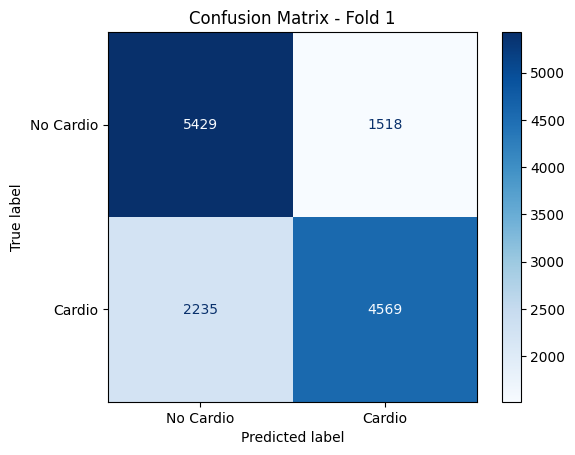


--- Fold 2 ---
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Fold Accuracy: 0.7299832739437132
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75      6947
           1       0.76      0.66      0.71      6804

    accuracy                           0.73     13751
   macro avg       0.73      0.73      0.73     13751
weighted avg       0.73      0.73      0.73     13751



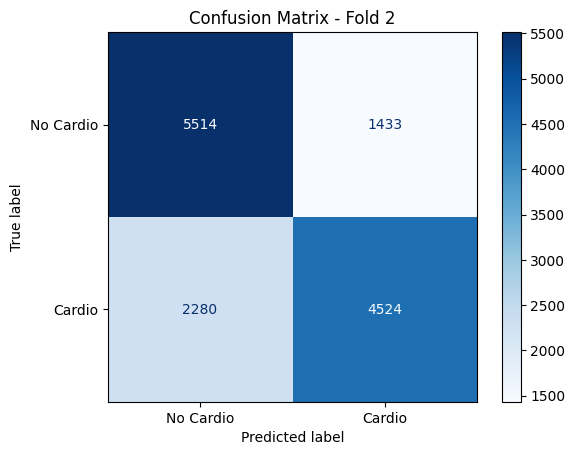


--- Fold 3 ---
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Fold Accuracy: 0.7358737546360264
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.79      0.75      6947
           1       0.76      0.68      0.72      6804

    accuracy                           0.74     13751
   macro avg       0.74      0.74      0.73     13751
weighted avg       0.74      0.74      0.73     13751



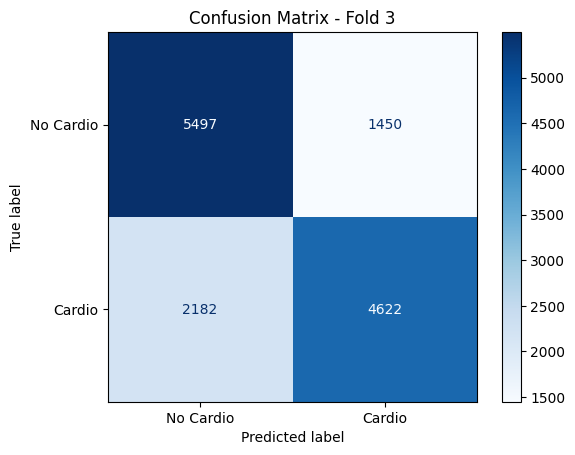


--- Fold 4 ---
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Fold Accuracy: 0.7286015562504545
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75      6947
           1       0.75      0.67      0.71      6804

    accuracy                           0.73     13751
   macro avg       0.73      0.73      0.73     13751
weighted avg       0.73      0.73      0.73     13751



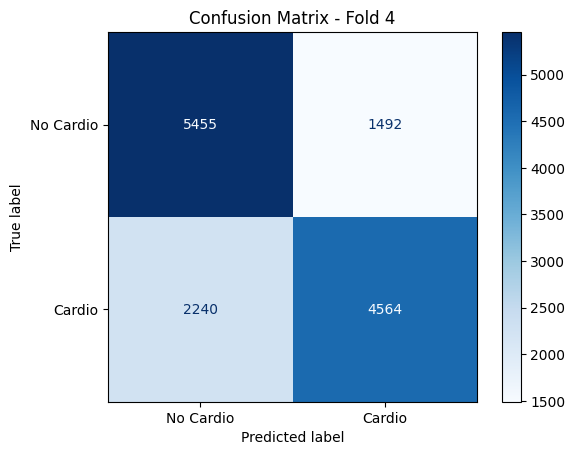


--- Fold 5 ---
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Fold Accuracy: 0.7290909090909091
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.82      0.75      6946
           1       0.78      0.63      0.70      6804

    accuracy                           0.73     13750
   macro avg       0.74      0.73      0.73     13750
weighted avg       0.74      0.73      0.73     13750



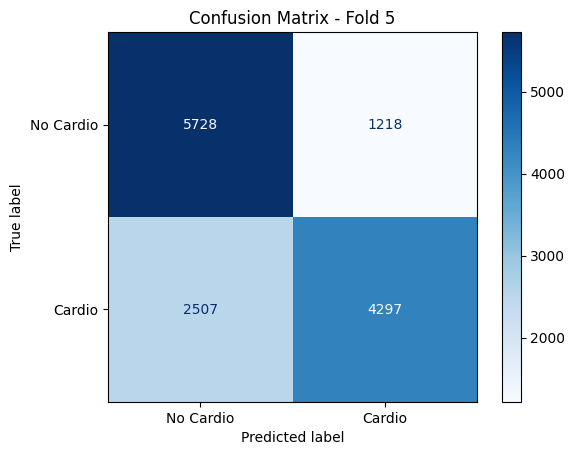


✅ Average Accuracy Across Folds: 0.7301247777021175


In [46]:
# Cross-validation loop using the hyperparamter tuned models and also implementing the f fold cross validation
for train_index, test_index in skf.split(X, y):
    print(f"\n--- Fold {fold} ---")
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Grid Search within fold
    grid_search = GridSearchCV(estimator=dt, param_grid=param_grid,
                               cv=3, n_jobs=-1, verbose=0, scoring='accuracy')
    grid_search.fit(X_train_fold, y_train_fold)

    # Predictions and evaluation
    rf_best = grid_search.best_estimator_
    y_pred_fold = rf_best.predict(X_test_fold)

    acc = accuracy_score(y_test_fold, y_pred_fold)
    accuracies.append(acc)

    print("Best Parameters:", grid_search.best_params_)
    print("Fold Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test_fold, y_pred_fold))

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test_fold,
        y_pred_fold,
        display_labels=["No Cardio", "Cardio"],
        cmap='Blues',
        values_format='d'
    )
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()
    
    fold += 1

# Average accuracy across folds
print("\n✅ Average Accuracy Across Folds:", np.mean(accuracies))

The average K fold accuracy is 73.01% meaning that the model is performing moderately well thus there is room for improvement.

**Confusion matrix**

1st fold is inconsistent with prediction value of 9998 true values which is quite less than from the other folds predicting 10019, 10025, 10038. The difference between the highest prediction and lowest is 121

When you look at the true predictions across all the folds they are consistent at an average of 10256 unlike on the first fold where there is some inconsistence that the model predicts over 9000 true values


**Precision**

The model's precision through both the cardio and no cardio groups is not consistent across all the folds

Precision is higher for class cardiovascular disease meaning that when the model predicts cardiovascular disease and its often correct. The values are not consistent across folds.


**Recall**

Recall is higher for the class cardiovascular disease meaning that the model is better at identifying actual cardiovascular diseases.

**F 1 score**

The F 1 scores are relatively balanced meaning that there are reasonable trade offs between precision and recall



In [47]:
# Cross-validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV ROC AUC: 0.763 ± 0.003


The value of area under curve which is 0.763 means that the model is a good predictor for cardiovascualr disease

In [48]:
from sklearn.metrics import roc_curve, auc

In [49]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

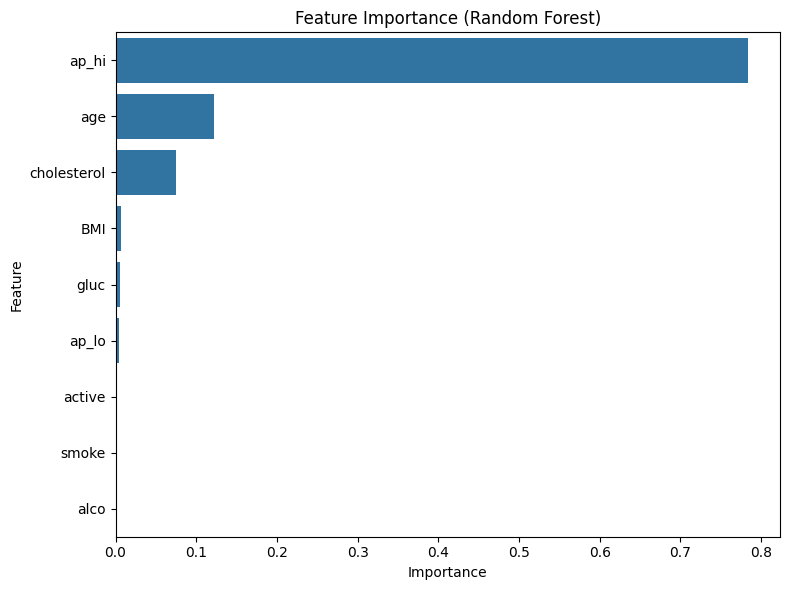

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from best model
importances = grid_search.best_estimator_.feature_importances_
feature_names = X.columns
importance_data = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_data = importance_data.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_data)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()


The most important predictor features in the dataset are blood pressure systolic, age, cholesterol, body mass index, glucose, blood pressure diastolic, physically active, smoking status and alcoholism last

# NAIVE BAYES CLASSIFIER

This is model helps in calculation of probabilities for each class thus predicting the class with the highest probability

In [51]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler


# Select features
features = [
    'age', 'ap_hi', 'ap_lo',
    'BMI', 'smoke', 'active', 'gluc', 'cholesterol', 'alco'
]
X = data[features]
y = data['cardio']

# Standardize features (important for Naive Bayes with continuous features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize Gaussian Naive Bayes
nr = GaussianNB()

# Hyperparameter grid (minimal for Naive Bayes, mainly for var_smoothing)
param_grid = {
    'var_smoothing': np.logspace(-9, -6, 4)
}

# Track results
fold = 1
accuracies = []



The best features for the model are selected and the model is trained with hyperparamter tuning involved for the model to achieve optimal perfromance at the various k folds


--- Fold 1 ---
Best Parameters: {'var_smoothing': np.float64(1e-09)}
Fold Accuracy: 0.7064940731583158
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.81      0.74      6947
           1       0.76      0.60      0.67      6804

    accuracy                           0.71     13751
   macro avg       0.72      0.71      0.70     13751
weighted avg       0.72      0.71      0.70     13751



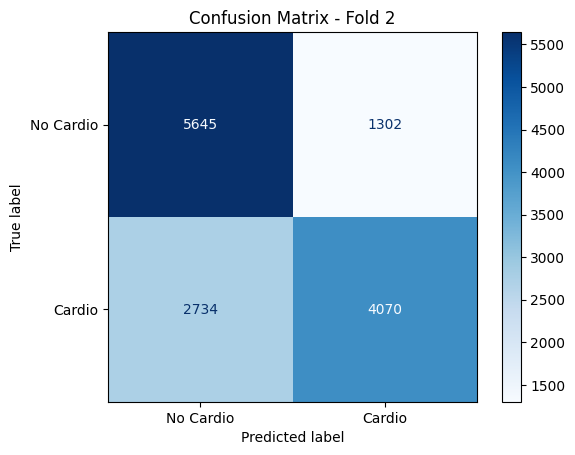


--- Fold 3 ---
Best Parameters: {'var_smoothing': np.float64(1e-09)}
Fold Accuracy: 0.7128208857537633
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.83      0.74      6947
           1       0.77      0.60      0.67      6804

    accuracy                           0.71     13751
   macro avg       0.72      0.71      0.71     13751
weighted avg       0.72      0.71      0.71     13751



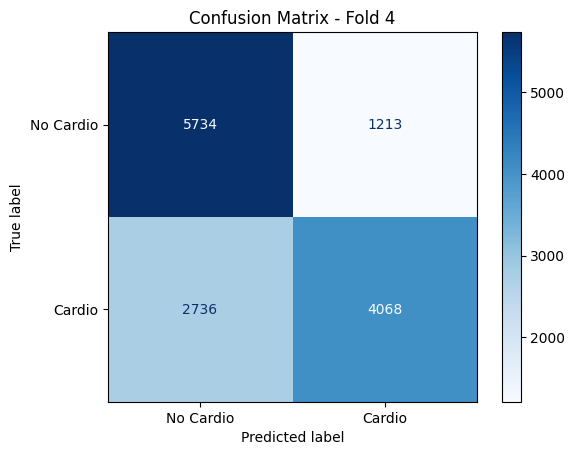


--- Fold 5 ---
Best Parameters: {'var_smoothing': np.float64(1e-09)}
Fold Accuracy: 0.7099120063995346
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.82      0.74      6947
           1       0.76      0.60      0.67      6804

    accuracy                           0.71     13751
   macro avg       0.72      0.71      0.71     13751
weighted avg       0.72      0.71      0.71     13751



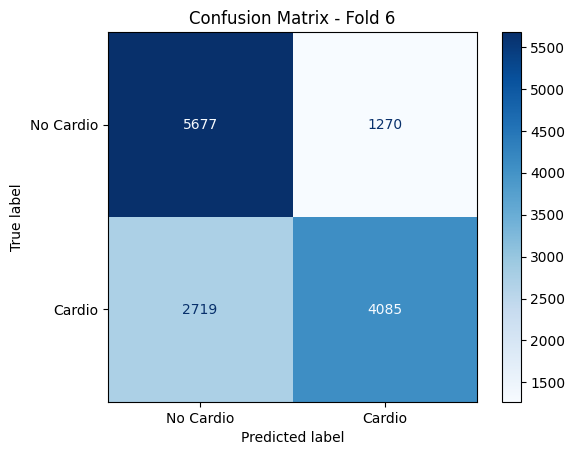


--- Fold 7 ---
Best Parameters: {'var_smoothing': np.float64(1e-09)}
Fold Accuracy: 0.7110028361573704
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.82      0.74      6947
           1       0.77      0.60      0.67      6804

    accuracy                           0.71     13751
   macro avg       0.72      0.71      0.71     13751
weighted avg       0.72      0.71      0.71     13751



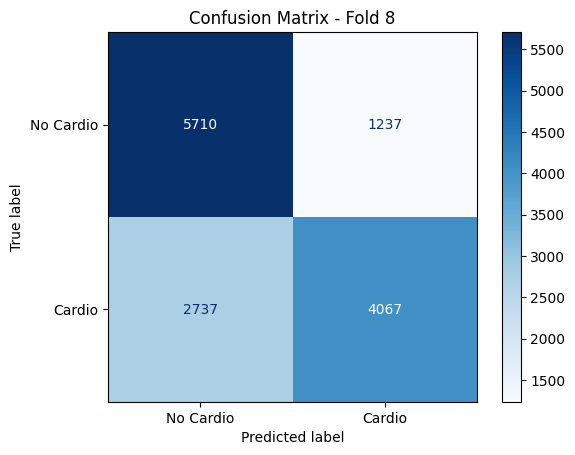


--- Fold 9 ---
Best Parameters: {'var_smoothing': np.float64(1e-09)}
Fold Accuracy: 0.7095272727272727
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.81      0.74      6946
           1       0.76      0.60      0.67      6804

    accuracy                           0.71     13750
   macro avg       0.72      0.71      0.71     13750
weighted avg       0.72      0.71      0.71     13750



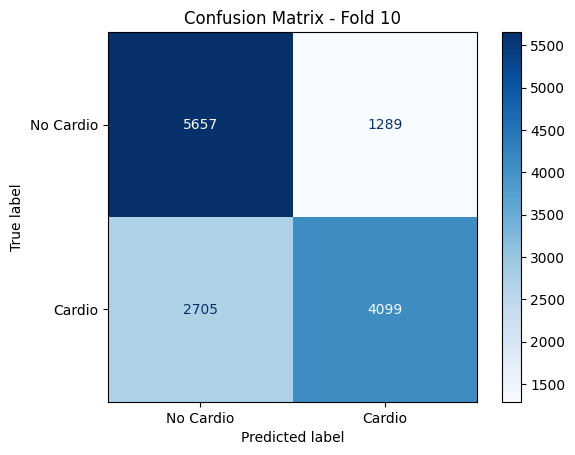


✅ Average Accuracy Across Folds: 0.7099514148392514


In [52]:
# Cross-validation loop
for train_index, test_index in skf.split(X_scaled, y):
    print(f"\n--- Fold {fold} ---")
    fold += 1
    X_train_fold, X_test_fold = X_scaled[train_index], X_scaled[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Grid Search inside the fold
    grid_search = GridSearchCV(estimator=nr, param_grid=param_grid,
                               cv=3, n_jobs=-1, verbose=0, scoring='accuracy')
    grid_search.fit(X_train_fold, y_train_fold)

    # Predictions and evaluation
    nr_best = grid_search.best_estimator_
    y_pred_fold = nr_best.predict(X_test_fold)

    acc = accuracy_score(y_test_fold, y_pred_fold)
    accuracies.append(acc)

    print("Best Parameters:", grid_search.best_params_)
    print("Fold Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test_fold, y_pred_fold))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test_fold,
        y_pred_fold,
        display_labels=['No Cardio', 'Cardio'],
        cmap='Blues',
        values_format='d'
    )
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

    fold += 1

# Final average accuracy
print("\n✅ Average Accuracy Across Folds:", np.mean(accuracies))


The Naive Bayes classifier has the average accuracy of 70.99% 

**Confusion matrix**

The predictions across all folds is a bit consistent with the lowest true predictions as 9715 and the highest as 9802 out of the 13750 observations

**Precision**

The precision for both class is a bit consistent since the values dont deviate much from each other

precision is higher for class cardio meaning that when the model predicts cardio its often correct.


**Recall**

Recall is higher for class no cardio meaning that the model is better at identifying actual no cardiovascular disease.

**F 1 score**

On the class no cardio, there is a balance between precision and recall at 74%

On the class cardio, there is a balance between precision and recall at 67%

This perfectly consistent across all the folds



In [53]:
# Cross-validation
cv_scores = cross_val_score(nr, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV ROC AUC: 0.777 ± 0.003


Since the area under the curve is 0.777, this means that the model is good

In [54]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler


# LOGISITIC REGRESSION

This is a binary predictor model that predicts a dependent data variable by analyzing the relationship between one or more existing independent variables.


In [55]:
from sklearn.linear_model import LogisticRegression

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the Logistic Regression model
lr = LogisticRegression(max_iter=1000, solver='saga')


# Define hyperparameter grid
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 1, 10],
    'l1_ratio': [0, 0.5, 1]  # Only relevant for elasticnet
}

# Track results
fold = 1
accuracies = []



The best features selected are tested at 30% of the data and the k fold cross validation is implemented to enable us assess the model perfromance through all the folds.

Then the model is fitted for logistic regression with maximum set of ephocs which is 1000 and the grid search is implemented to enable hyperparamter tuning of the model and the best paramtere picked up


--- Fold 1 ---
Best Parameters: {'C': 0.1, 'l1_ratio': 0.5, 'penalty': 'l1'}
Fold Accuracy: 0.7258381208639372
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.79      0.74      6947
           1       0.75      0.66      0.71      6804

    accuracy                           0.73     13751
   macro avg       0.73      0.73      0.72     13751
weighted avg       0.73      0.73      0.72     13751



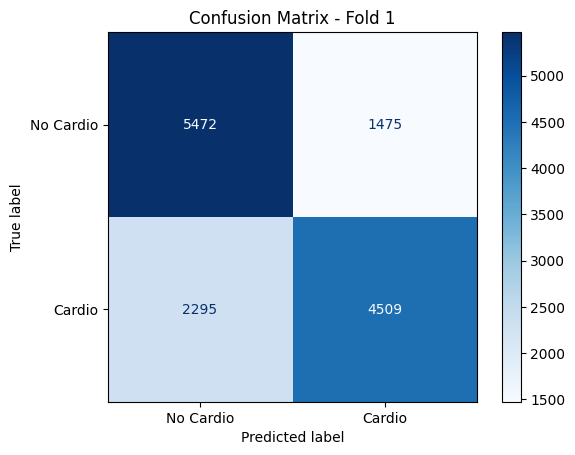


--- Fold 2 ---
Best Parameters: {'C': 10, 'l1_ratio': 0, 'penalty': 'elasticnet'}
Fold Accuracy: 0.7283833902988873
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75      6947
           1       0.76      0.66      0.71      6804

    accuracy                           0.73     13751
   macro avg       0.73      0.73      0.73     13751
weighted avg       0.73      0.73      0.73     13751



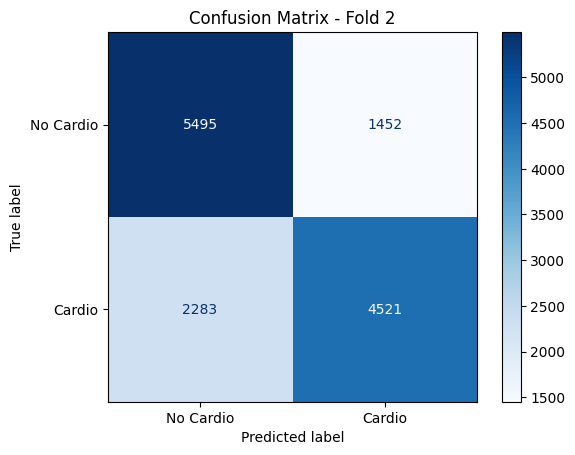


--- Fold 3 ---
Best Parameters: {'C': 0.1, 'l1_ratio': 0.5, 'penalty': 'l2'}
Fold Accuracy: 0.7300559959275689
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75      6947
           1       0.76      0.67      0.71      6804

    accuracy                           0.73     13751
   macro avg       0.73      0.73      0.73     13751
weighted avg       0.73      0.73      0.73     13751



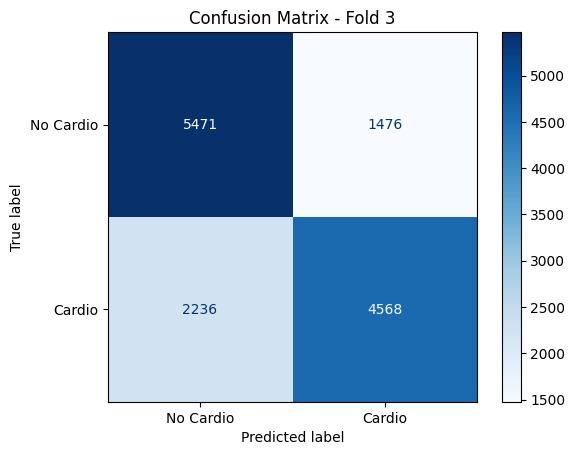


--- Fold 4 ---
Best Parameters: {'C': 0.01, 'l1_ratio': 0.5, 'penalty': 'elasticnet'}
Fold Accuracy: 0.7258381208639372
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.79      0.74      6947
           1       0.75      0.66      0.71      6804

    accuracy                           0.73     13751
   macro avg       0.73      0.73      0.72     13751
weighted avg       0.73      0.73      0.72     13751



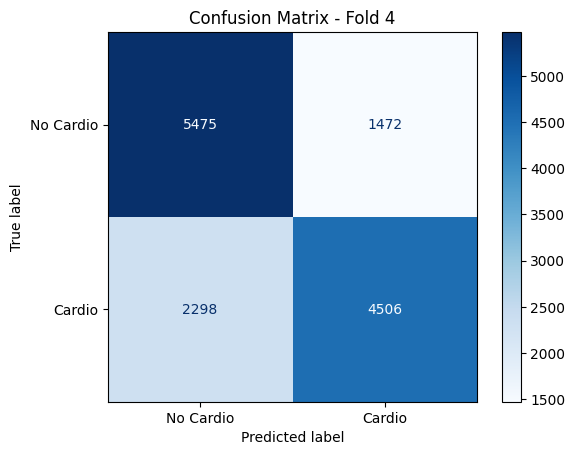


--- Fold 5 ---
Best Parameters: {'C': 0.1, 'l1_ratio': 1, 'penalty': 'l1'}
Fold Accuracy: 0.7257454545454546
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      6946
           1       0.75      0.67      0.71      6804

    accuracy                           0.73     13750
   macro avg       0.73      0.73      0.72     13750
weighted avg       0.73      0.73      0.72     13750



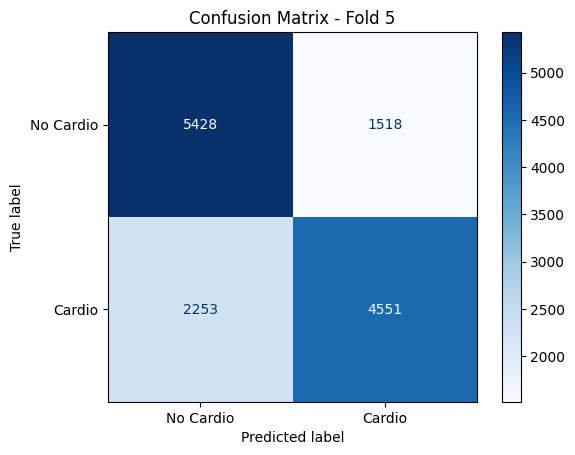


✅ Average Accuracy Across Folds: 0.727172216499957


In [56]:
# Cross-validation loop
for train_index, test_index in skf.split(X_scaled, y):
    print(f"\n--- Fold {fold} ---")
    X_train_fold, X_test_fold = X_scaled[train_index], X_scaled[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # GridSearchCV inside each fold
    grid_search = GridSearchCV(estimator=lr, param_grid=param_grid,
                               cv=3, n_jobs=-1, verbose=0, scoring='accuracy')
    grid_search.fit(X_train_fold, y_train_fold)

    # Predictions and evaluation
    lr_best = grid_search.best_estimator_
    y_pred_fold = lr_best.predict(X_test_fold)

    acc = accuracy_score(y_test_fold, y_pred_fold)
    accuracies.append(acc)

    print("Best Parameters:", grid_search.best_params_)
    print("Fold Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test_fold, y_pred_fold))

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test_fold,
        y_pred_fold,
        display_labels=['No Cardio', 'Cardio'],
        cmap='Blues',
        values_format='d'
    )
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

    fold += 1

# Average accuracy across folds
print("\n✅ Average Accuracy Across Folds:", np.mean(accuracies))


The average accuracy level across all the folds is 72.72% 

**Confusion matrix**

The confusion matrix shows that the model on average predicts the true positives and negatives from a number of participants which is 13752. But the true predictions made are inconsistent through out all the folds

**Precision**

The models precision through out all folds is relatively consistent though not perfectly

precision is higher for class cardio meaning when it predicts cardio its more correct oftenly.

**Recall**

Recall is higer for class no cardio meaning that the model is better at identifying cardiovascualr disease

**F 1 score**

There is a balance between precision and recall in the class no cardio at 74% on average across folds

There is a balance between precision and recall in the class cardio at 71% on average across folds and this is consistent



In [57]:
# Cross-validation
cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV ROC AUC: 0.786 ± 0.003


The area under curve is 0.786 meaning that the model is good predictor of cardiovascualr disease

# XG BOOST MODEL

Extreme gradient boosting is a distributed, open-source machine learning library that uses gradient boosted decision trees, a supervised learning boosting algorithm that makes use of gradient descent. It is known for its speed, efficiency and ability to scale well with large datasets.

In [58]:
!pip install xgboost

In [59]:
###Use of the xg boost classifier model
from xgboost import XGBClassifier
# Select only the significant features (based on your ANOVA results)
features = [
    'age', 'ap_hi', 'ap_lo',
    'BMI', 'smoke', 'active', 'gluc', 'cholesterol', 'alco'
]
X = data[features]
y = data['cardio']

# Optional: Standardize features (not required for XGBoost, but fine to include)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the XGBoost model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Track results
fold = 1
accuracies = []




The best features from the anova analysis are used in training the xg boost classification model and the k fold cross validation is used in the model with the best parameters from thr grid serach to ensure that the best paramaters are picked on.


--- Fold 1 ---
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}
Fold Accuracy: 0.7327467093302306
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.78      0.75      6947
           1       0.75      0.69      0.72      6804

    accuracy                           0.73     13751
   macro avg       0.73      0.73      0.73     13751
weighted avg       0.73      0.73      0.73     13751



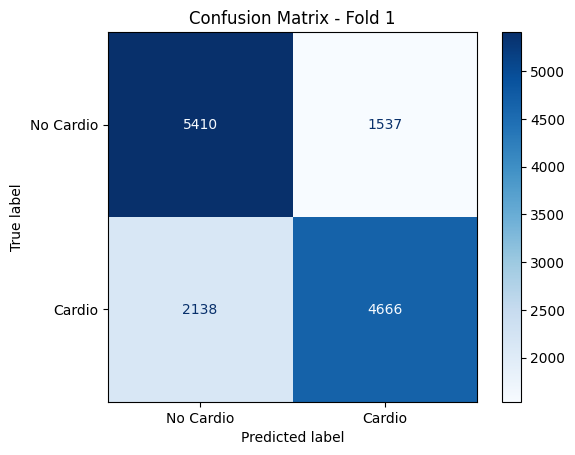


--- Fold 2 ---
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Fold Accuracy: 0.7366009744745836
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.79      0.75      6947
           1       0.76      0.68      0.72      6804

    accuracy                           0.74     13751
   macro avg       0.74      0.74      0.74     13751
weighted avg       0.74      0.74      0.74     13751



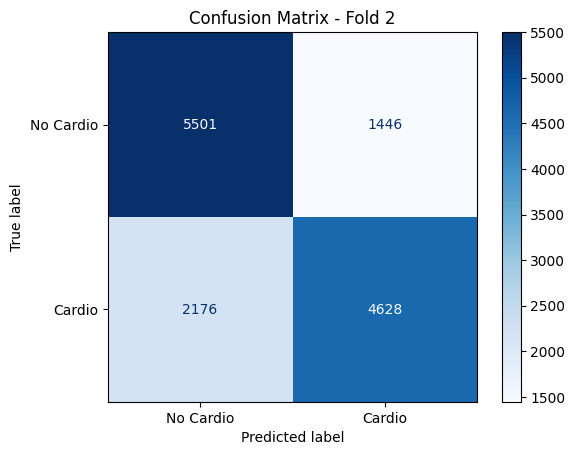


--- Fold 3 ---
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Fold Accuracy: 0.7382735801032653
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.78      0.75      6947
           1       0.76      0.69      0.72      6804

    accuracy                           0.74     13751
   macro avg       0.74      0.74      0.74     13751
weighted avg       0.74      0.74      0.74     13751



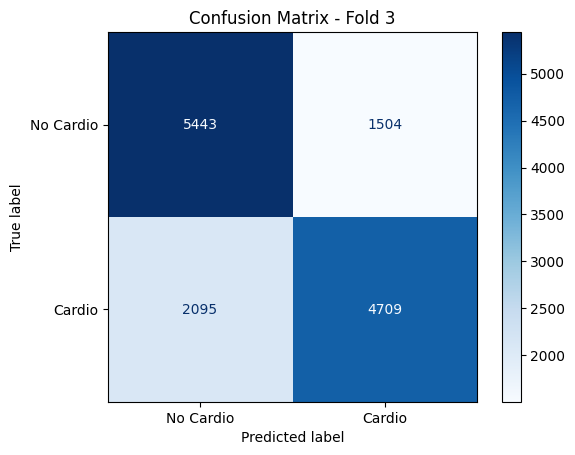


--- Fold 4 ---
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1}
Fold Accuracy: 0.7333284852010763
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75      6947
           1       0.76      0.68      0.72      6804

    accuracy                           0.73     13751
   macro avg       0.74      0.73      0.73     13751
weighted avg       0.74      0.73      0.73     13751



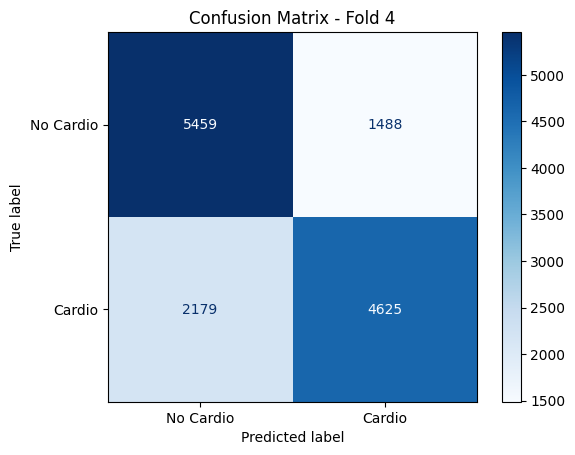


--- Fold 5 ---
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Fold Accuracy: 0.7365090909090909
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.78      0.75      6946
           1       0.76      0.69      0.72      6804

    accuracy                           0.74     13750
   macro avg       0.74      0.74      0.74     13750
weighted avg       0.74      0.74      0.74     13750



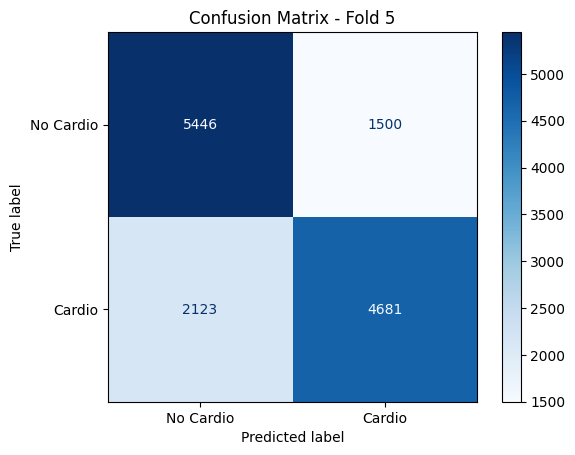


✅ Average Accuracy Across Folds: 0.7354917680036493


In [60]:
# Cross-validation loop for the XG Boost calssification model
for train_index, test_index in skf.split(X_scaled, y):
    print(f"\n--- Fold {fold} ---")
    X_train_fold, X_test_fold = X_scaled[train_index], X_scaled[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # GridSearchCV inside each fold
    grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                               cv=3, n_jobs=-1, verbose=0, scoring='accuracy')
    grid_search.fit(X_train_fold, y_train_fold)

    # Predictions and evaluation
    xgb_best = grid_search.best_estimator_
    y_pred_fold = xgb_best.predict(X_test_fold)

    acc = accuracy_score(y_test_fold, y_pred_fold)
    accuracies.append(acc)

    print("Best Parameters:", grid_search.best_params_)
    print("Fold Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test_fold, y_pred_fold))

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test_fold,
        y_pred_fold,
        display_labels=['No Cardio', 'Cardio'],
        cmap='Blues',
        values_format='d'
    )
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

    fold += 1

# Average accuracy across folds
print("\n✅ Average Accuracy Across Folds:", np.mean(accuracies))

The model has an average accuracy of 73.52% across all the folds which is moderate

**Confusion matrix**

The confusion matrix for the XG boost doesnt have any inconsistencies across folds because it correctly predicts the true values across all folds with an average value of 1000 across all folds

**Precision**

Precision is higher for class cardio meaning that when the model predicts cardio its often correct.

We can also see consistence in the model's predictions of cardio and no cardio


**Recall**

Recall is higher for class no cardio meaning that the model is better at predicting actual no cardios

**F 1 score**

There is a balance between recall and precision for no cardio at 75%

There is balance for recall and precision for cardio at 72% 



In [61]:
# Cross-validation
cv_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV ROC AUC: 0.792 ± 0.002


The models area under curve value of 0.792 means that the model is performing so well

# Learning curves for the models

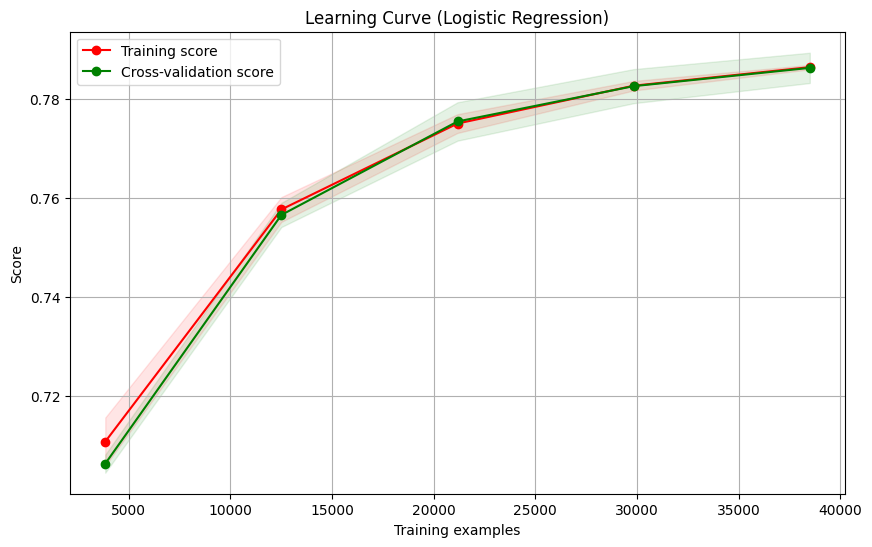

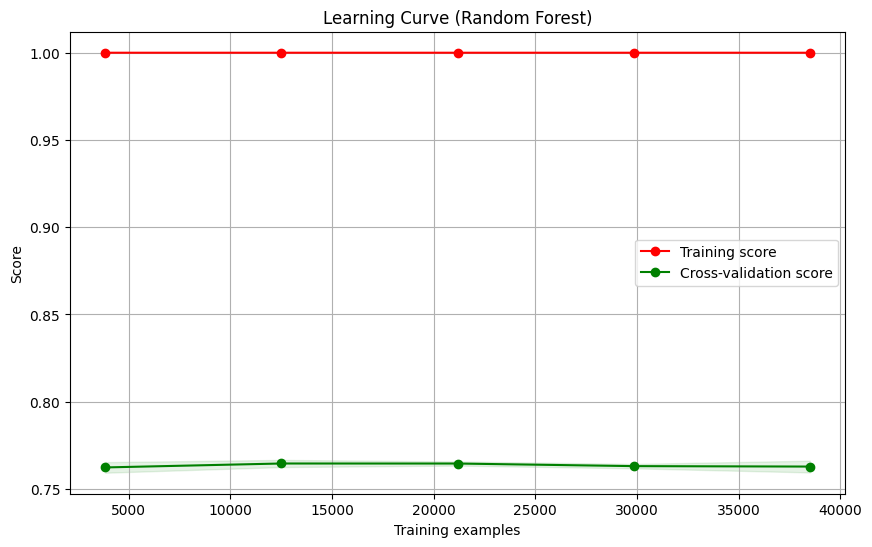

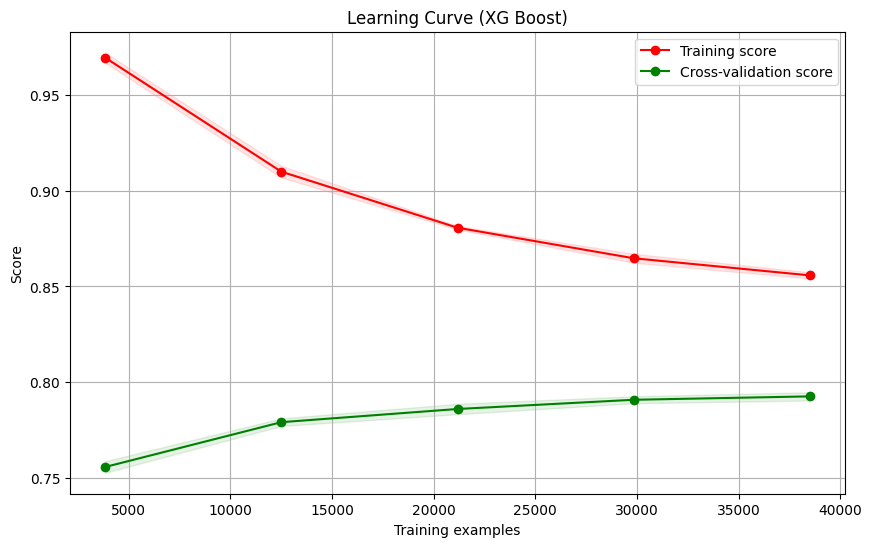

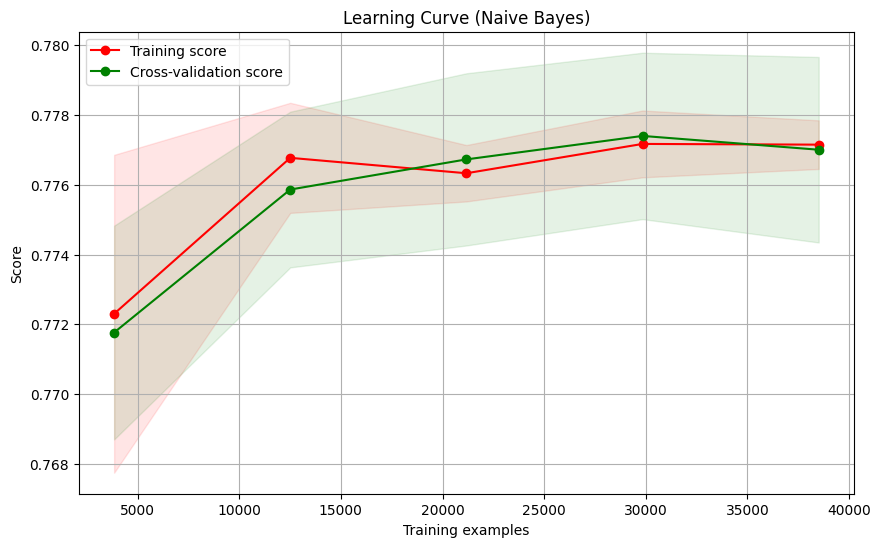

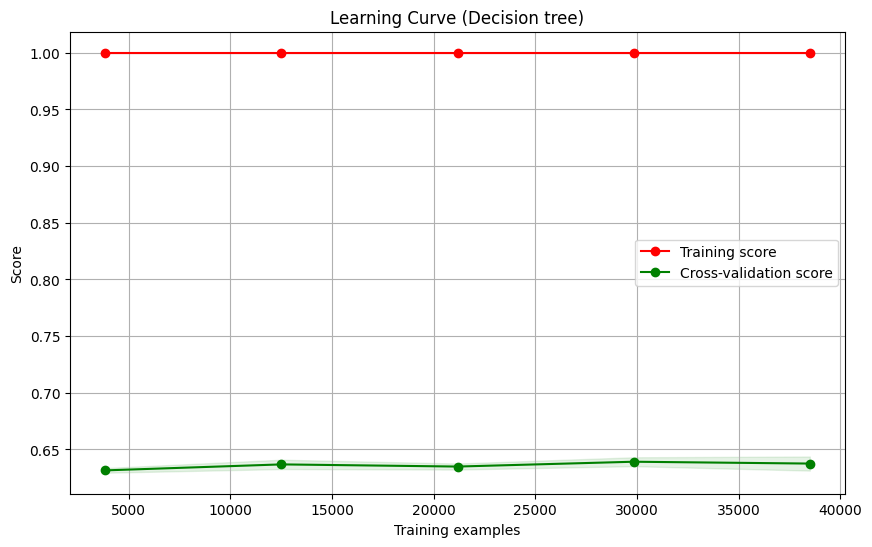

In [62]:
def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=None):
    plt.figure(figsize=(10,6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(.1, 1.0, 5),
        scoring='roc_auc')
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1,
                     color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

plot_learning_curve(lr, "Learning Curve (Logistic Regression)", X_train, y_train, cv=5)
plot_learning_curve(rf, "Learning Curve (Random Forest)", X_train, y_train, cv=5)
plot_learning_curve(xgb, "Learning Curve (XG Boost)", X_train, y_train, cv=5)
plot_learning_curve(nr, "Learning Curve (Naive Bayes)", X_train, y_train, cv=5)
plot_learning_curve(dt, "Learning Curve (Decision tree)", X_train, y_train, cv=5)

**Logistic regression**

The model shows that its a good fit with low bias and low variance therefore its complex enough to capture underlying data patterns plus its not over fitting to the training data.

**Random forest**

This curve shows that the model is performing well on training data therefore there is a possibility that our model has over fitted on training data and more so the model is not generalising well on unseen data. This is evident by the wide gap between the 2 curves

**XG Boost**

The training score curve shows that the models performance on training data is decreasing as the model is being trained more on different ephocs and since the line is still high there seems to be some overfitting.

This model means that the more its trained to more data, its reduces on overfitting meaning that its a good model to use


**Naive Bayes**

The training score curve shows various fluctuations in the data but which seem to be abit stable with values ranging from 0.772 to 0.778. And since the cross validation score shows the similar tend and the gap between them is not so wide, meaning the model is generalising well and no model overfitting

**Decision tree classfier**

This curve shows that the model is perfroming well on training data therefore there is a possibility that our model has over fitted on training data and more so the model is not generalising well on unseen data and this is evidenced by the wide gap between the 2 curves

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import cross_val_score
# Dictionary of trained and tuned models
models = {
    'XGBoost': xgb_best,
    'Random Forest': rf_best,
    'Logistic Regression': lr_best,
    'Decision Tree': dt_best,
    'Naive Bayes': nr_best
}

# Collect cross-validated performance metrics
results = []

for name, model in models.items():
    print(f"\n📈 Evaluating: {name}")

    acc_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    roc_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc')

    results.append({
        'Model': name,
        'Accuracy Mean': acc_scores.mean(),
        'Accuracy Std': acc_scores.std(),
        'ROC AUC CV Mean': roc_scores.mean(),
        'ROC AUC CV Std': roc_scores.std()
    })
    # Create summary DataFrame
evaluation_df = pd.DataFrame(results).sort_values(by="ROC AUC CV Mean", ascending=False).reset_index(drop=True)

# Print stats
print("\n📋 Cross-Validation Summary:")
print(evaluation_df)



📈 Evaluating: XGBoost

📈 Evaluating: Random Forest

📈 Evaluating: Logistic Regression

📈 Evaluating: Decision Tree

📈 Evaluating: Naive Bayes

📋 Cross-Validation Summary:
                 Model  Accuracy Mean  Accuracy Std  ROC AUC CV Mean  \
0              XGBoost       0.735259      0.003814         0.801040   
1        Decision Tree       0.730430      0.002353         0.791731   
2        Random Forest       0.730343      0.002414         0.791114   
3  Logistic Regression       0.727099      0.003332         0.790074   
4          Naive Bayes       0.709937      0.001740         0.776796   

   ROC AUC CV Std  
0        0.004084  
1        0.003949  
2        0.003842  
3        0.005004  
4        0.003676  


The analysis shows that XG Boost is the best model since it has the highest receiver operating characterisitc area under the curve with a value of 0.8011 and it has the highest mean accuracy as compared to the other classifiers.

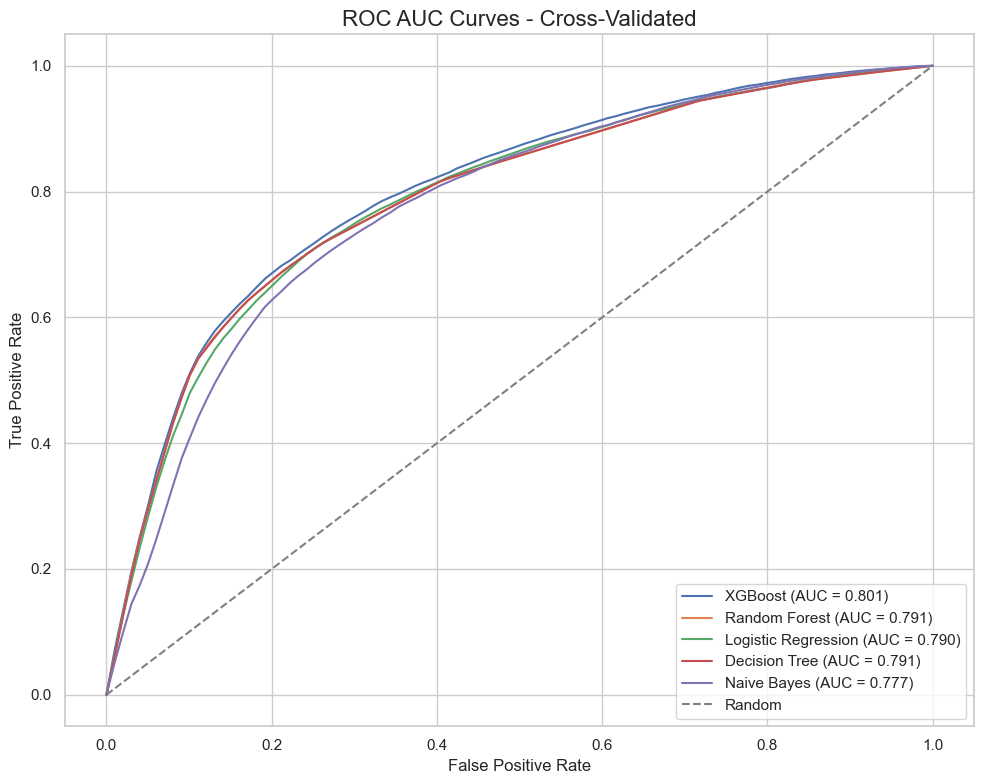

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Plot setup
plt.figure(figsize=(10, 8))
plt.title("ROC AUC Curves - Cross-Validated", fontsize=16)

# Loop through models
for name, model in models.items():
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X_scaled, y):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    plt.plot(mean_fpr, mean_tpr, label=f"{name} (AUC = {mean_auc:.3f})")

# Plot baseline
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


The graph shows that the xg boost model is the best with the highest area under curve followed by the random forest model, logisitc regression, decision tree classifier, naive bayes classification model

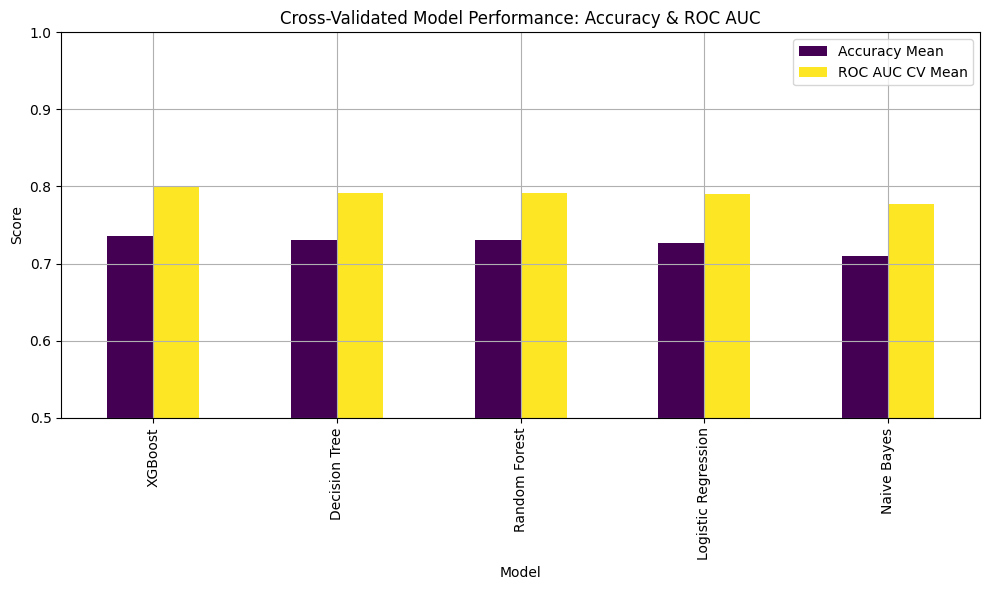

In [64]:

# Plot bar chart
evaluation_df.set_index("Model")[["Accuracy Mean", "ROC AUC CV Mean"]].plot(
    kind='bar',
    figsize=(10, 6),
    ylim=(0.5, 1),
    grid=True,
    colormap='viridis'
)
plt.title("Cross-Validated Model Performance: Accuracy & ROC AUC")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


The visualisation shows the distribution of the models' performance in regards to accuracy, receiver operating characteristic area under the curve 

In [65]:
!pip install shap


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


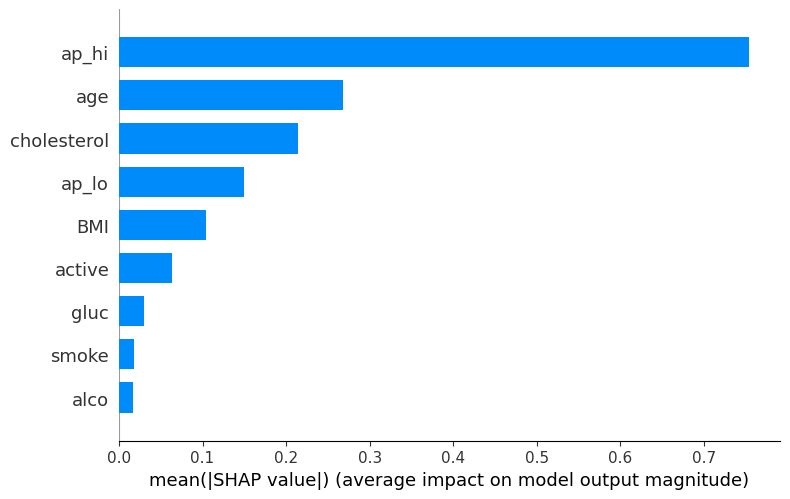

In [66]:
import shap
# Make sure you're using the original feature names
X_data = pd.DataFrame(X_scaled, columns=X.columns)

# ✅ Step 1: Create SHAP Explainer for XGBoost
explainer = shap.Explainer(xgb_best)

# ✅ Step 2: Compute SHAP values
shap_values = explainer(X_data)

# ✅ Step 3: Plot Global Feature Importance
plt.title("Global Feature Importance (SHAP Summary - Bar)")
shap.summary_plot(shap_values, X_data, plot_type="bar")


The xgboost model is much impacted on by the blood pressure systolic, age, cholestrol levels, blood pressure diastolic, body mass index, physical activity, glucose levels, smoking status, and alcohol

# MODEL DEPLOYMENT

In [67]:
###Installation of joblib
!pip install joblib


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
##Saving the model as joblib file
import joblib
joblib.dump(model, 'xgb_best.pkl')

['xgb_best.pkl']

Installation of the flask library to enable deployment of the model

In [69]:
!pip install flask



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
from flask import Flask, request, jsonify
import threading
import joblib
import numpy as np

app = Flask(__name__)
model = joblib.load('xgb_best.pkl') 

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json(force=True)
    features = np.array(data['features']).reshape(1, -1)
    prediction = model.predict(features)
    return jsonify({'prediction': int(prediction[0])})

# Run Flask in a separate thread (so it doesn't block the notebook)
def run_app():
    app.run(port=5000)

thread = threading.Thread(target=run_app)
thread.start()


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


# CONCLUSION

Basing on the exploratory data analysis all the variables in the dataset apart from gender have a positive correlation with cardiovascular disease and from the analysis those variables were used in feature selection.

The models were depployed and the best was XG Boost model because it had the highest area under curve, highest accuracy, consistent f1 score, recall and precision, its learning curve was performing better as its trained on more data.

Our optional deployment plan of the model is on flask though still in need of a production server